# SATX House Hack — Property Cashflow Analysis

**Inputs:** `data/final/ranked_zip_scores.csv` (output of main pipeline)  
**Purpose:** For each top-ranked ZIP, model realistic monthly cashflow and 3-year hold P&L under house-hack conditions.

---

### Two phases, modeled separately

**Phase 1 — House Hack (while stationed at BAMC)**  
You live in one unit/room. Tenants pay part of the mortgage. Your net monthly cost = PITI − rental income from occupied units.

**Phase 2 — Full Rental (post-PCS)**  
You're gone. Property becomes a full rental. Net cashflow = total rent − all operating expenses.

Both phases matter. A property that barely works as a house hack might cashflow strongly as a full rental — or collapse. You need to see both before deciding.

---

### Key assumptions (all adjustable in Cell 2)

| Parameter | Value | Source |
|-----------|-------|--------|
| Loan type | VA (0% down) | Your eligibility |
| Interest rate | 6.875% | Feb 2026 VA 30yr average |
| VA funding fee | 2.15% (rolled in) | First-time VA use |
| Property tax | 2.2% of value/yr | Bexar County effective rate |
| Insurance | $1.50 per $1,000 value/yr | SA market estimate |
| Vacancy reserve | 5% of gross rent | Conservative SA assumption |
| Maintenance reserve | 9% of gross rent | Between your 8–10% range |
| Appreciation | $0 | Conservative — downside protection |
| HOA | $0 | Adjust per property |

> **All numbers here are projections, not guarantees.** Verify tax rate with Bexar CAD, get real insurance quotes, and validate rents with actual active listings before making any decision.

## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT       = Path('..').resolve()
DATA_FINAL = ROOT / 'data' / 'final'
SRC        = ROOT / 'src'
sys.path.insert(0, str(SRC))

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

POSITIVE_COLOR = '#27ae60'
NEGATIVE_COLOR = '#e74c3c'
NEUTRAL_COLOR  = '#2980b9'
WARN_COLOR     = '#f39c12'

# Load scored ZIPs — pipeline must have been run at least once
scores_path = DATA_FINAL / 'ranked_zip_scores.csv'
if not scores_path.exists():
    raise FileNotFoundError(
        f"'{scores_path}' not found. Run: python main.py --no-google-maps"
    )

scored = pd.read_csv(scores_path, dtype={'zip': str})
scored['zip'] = scored['zip'].str.zfill(5)
scored = scored.sort_values('rank').reset_index(drop=True)

print(f"Loaded {len(scored)} scored ZIPs")
print(f"Columns: {list(scored.columns)}")
print(f"\nTop ZIPs by rank:")
print(scored[['rank','zip','median_home_value','median_rent','rent_to_price',
              'crime_per_1k','commute_minutes','final_score']].to_string(index=False))

Loaded 7 scored ZIPs
Columns: ['zip', 'median_home_value', 'median_rent', 'owner_occ_pct', 'median_hh_income', 'crime_per_1k', 'commute_minutes', 'commute_miles', 'zhvi_cov', 'rent_to_price', 'rent_to_price_capped', 'crime_log', 'score_rent_to_price', 'score_crime', 'score_owner_occupancy', 'score_commute', 'score_stability', 'final_score', 'rank', 'weighted_rent_to_price', 'weighted_crime', 'weighted_owner_occupancy', 'weighted_commute', 'weighted_stability']

Top ZIPs by rank:
 rank   zip  median_home_value  median_rent  rent_to_price  crime_per_1k  commute_minutes  final_score
    1 78239      213815.893779  1445.722222       0.081138     51.669838        15.400040     0.713840
    2 78109      244062.707683  1686.329189       0.082913     42.889519        22.095258     0.680003
    3 78225      124593.247124  1275.000000       0.122800    355.310825        16.420532     0.607833
    4 78244      212064.301457  1529.921245       0.086573    114.919689        13.838541     0.555386
 

---
## 1. Financial Parameters

**Edit this cell only.** Everything downstream reads from these variables.

The rate is the most sensitive lever — run the sensitivity analysis in Section 5 to see exactly how much it matters.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# ADJUST THESE — everything else is computed from them
# ══════════════════════════════════════════════════════════════════════════════

# ── Loan parameters ───────────────────────────────────────────────────────────
LOAN_TYPE          = 'VA'        # 'VA' or 'Conventional'
DOWN_PAYMENT_PCT   = 0.00        # 0.00 = VA no-down. Set 0.05 for conventional comp
INTEREST_RATE      = 0.06875     # Feb 2026 VA 30yr. Check: https://www.bankrate.com
LOAN_TERM_YEARS    = 30

# VA-specific
VA_FUNDING_FEE_PCT = 0.0215      # 2.15% first use, 3.30% if subsequent
ROLL_FUNDING_FEE   = True        # Roll fee into loan (common for 0%-down buyers)

# Conventional-specific (only used when LOAN_TYPE = 'Conventional')
PMI_ANNUAL_PCT     = 0.0085      # ~0.85% — drops off at 80% LTV (~11 years at 5% down)

# ── Operating costs (% of gross annual rent) ──────────────────────────────────
VACANCY_RATE       = 0.05        # 5% — one month empty every 20 months
MAINTENANCE_PCT    = 0.09        # 9% — midpoint of your 8–10% range
MGMT_FEE_PCT       = 0.00        # 0% while self-managing. Set 0.08 for PCS handoff

# ── Fixed annual costs ────────────────────────────────────────────────────────
PROPERTY_TAX_PCT   = 0.022       # 2.2% of home value — Bexar County effective rate
                                  # Verify at: https://bcad.org
INSURANCE_PER_1K   = 1.50        # $1.50 per $1,000 of home value per year (SA estimate)
HOA_MONTHLY        = 0           # Set per property. Many SA SFH = $0

# ── House hack parameters ─────────────────────────────────────────────────────
# What fraction of the property do you rent out while you live there?
# Duplex: 0.50 (one of two units). SFH 3BR renting 2 rooms: 0.67. ADU: varies.
HACK_RENT_FRACTION = 0.50        # Start conservative. Adjust per property type.

# ── Holding period ────────────────────────────────────────────────────────────
HOLD_YEARS         = 3           # Typical military tour length
APPRECIATION_PCT   = 0.00        # $0 appreciation — conservative baseline

# ── Selling costs (at exit) ───────────────────────────────────────────────────
SELLING_COST_PCT   = 0.06        # Agent commission + closing costs (~6%)

# ══════════════════════════════════════════════════════════════════════════════
print("Parameters loaded:")
print(f"  Loan:          {LOAN_TYPE} | {DOWN_PAYMENT_PCT:.0%} down | {INTEREST_RATE:.3%} rate")
print(f"  Monthly costs: {VACANCY_RATE:.0%} vacancy | {MAINTENANCE_PCT:.0%} maintenance | {MGMT_FEE_PCT:.0%} mgmt")
print(f"  Property tax:  {PROPERTY_TAX_PCT:.1%}/yr | Insurance: ${INSURANCE_PER_1K}/1k/yr")
print(f"  House hack:    {HACK_RENT_FRACTION:.0%} of property rented while living there")
print(f"  Hold period:   {HOLD_YEARS} years | Appreciation: {APPRECIATION_PCT:.0%}/yr")

Parameters loaded:
  Loan:          VA | 0% down | 6.875% rate
  Monthly costs: 5% vacancy | 9% maintenance | 0% mgmt
  Property tax:  2.2%/yr | Insurance: $1.5/1k/yr
  House hack:    50% of property rented while living there
  Hold period:   3 years | Appreciation: 0%/yr


---
## 2. Cashflow Engine

Deterministic functions. No magic — every number is traceable to the parameters above.

In [3]:
def monthly_mortgage_payment(purchase_price, down_pct, annual_rate, term_years,
                              loan_type='VA', va_fee_pct=0.0215, roll_fee=True):
    """
    Compute monthly principal + interest payment.
    For VA loans: funding fee can be rolled into the loan balance.
    For conventional: standard P&I on purchase_price * (1 - down_pct).
    """
    down       = purchase_price * down_pct
    loan_base  = purchase_price - down

    if loan_type == 'VA' and roll_fee:
        loan_amount = loan_base + (loan_base * va_fee_pct)
    else:
        loan_amount = loan_base

    monthly_rate = annual_rate / 12
    n_payments   = term_years * 12

    if monthly_rate == 0:
        return loan_amount / n_payments, loan_amount

    payment = loan_amount * (monthly_rate * (1 + monthly_rate)**n_payments) /               ((1 + monthly_rate)**n_payments - 1)
    return payment, loan_amount


def monthly_operating_costs(purchase_price, annual_rent,
                             tax_pct, ins_per_1k, hoa_monthly,
                             vacancy_rate, maintenance_pct, mgmt_pct,
                             loan_type='Conventional', pmi_pct=0.0085,
                             down_pct=0.05, loan_balance=None):
    """
    All non-P&I monthly costs.
    Returns a dict so each line item is visible separately.
    """
    monthly_rent = annual_rent / 12

    costs = {
        'property_tax':  purchase_price * tax_pct / 12,
        'insurance':     purchase_price / 1000 * ins_per_1k / 12,
        'hoa':           hoa_monthly,
        'vacancy':       monthly_rent * vacancy_rate,
        'maintenance':   monthly_rent * maintenance_pct,
        'management':    monthly_rent * mgmt_pct,
    }

    # PMI only for conventional loans below 80% LTV
    if loan_type == 'Conventional' and loan_balance is not None:
        ltv = loan_balance / purchase_price
        costs['pmi'] = (loan_balance * pmi_pct / 12) if ltv > 0.80 else 0
    else:
        costs['pmi'] = 0

    return costs


def full_cashflow(row, params):
    """
    Full monthly cashflow model for one ZIP (using median home value and rent).
    Returns a dict with every line item for both phases.
    """
    price  = row['median_home_value']
    rent   = row['median_rent']           # monthly rent from ZORI
    annual_rent = rent * 12

    # ── Loan ────────────────────────────────────────────────────────────────
    pi, loan_bal = monthly_mortgage_payment(
        price, params['down_pct'], params['rate'], params['term'],
        loan_type=params['loan_type'],
        va_fee_pct=params['va_fee'], roll_fee=params['roll_fee']
    )
    down_payment = price * params['down_pct']

    # ── Operating costs (full rental baseline) ───────────────────────────
    ops = monthly_operating_costs(
        price, annual_rent,
        params['tax_pct'], params['ins_per_1k'], params['hoa'],
        params['vacancy'], params['maintenance'], params['mgmt'],
        loan_type=params['loan_type'], pmi_pct=params['pmi'],
        down_pct=params['down_pct'], loan_balance=loan_bal
    )

    total_ops    = sum(ops.values())
    total_piti   = pi + ops['property_tax'] + ops['insurance'] + ops['hoa'] + ops['pmi']

    # ── Phase 2: Full rental cashflow (post-PCS) ─────────────────────────
    # All units rented. Gross rent = ZORI median.
    phase2_gross   = rent
    phase2_expense = pi + total_ops
    phase2_net     = phase2_gross - phase2_expense

    # ── Phase 1: House hack cashflow (while living there) ─────────────────
    # You occupy part of property. Only HACK_RENT_FRACTION generates income.
    # Your personal housing cost = PITI - rental income from occupied fraction.
    hack_gross     = rent * params['hack_frac']
    # Operating costs scale with rented portion only
    hack_ops       = monthly_operating_costs(
        price, hack_gross * 12,
        params['tax_pct'], params['ins_per_1k'], params['hoa'],
        params['vacancy'], params['maintenance'], params['mgmt'],
        loan_type=params['loan_type'], pmi_pct=params['pmi'],
        down_pct=params['down_pct'], loan_balance=loan_bal
    )
    hack_expense   = pi + sum(hack_ops.values())
    # Your net monthly out-of-pocket (negative = you're RECEIVING money)
    hack_net_cost  = hack_expense - hack_gross

    # ── 3-year hold P&L ───────────────────────────────────────────────────
    # Modeled here as HOLD_YEARS of house-hack cashflow plus sale at exit.
    # Using $0 appreciation for conservatism.
    exit_price       = price * (1 + params['appreciation']) ** params['hold_years']
    selling_costs    = exit_price * params['sell_cost']
    remaining_loan   = _remaining_balance(loan_bal, params['rate'], params['term'], params['hold_years'])
    # Sale proceeds are net cash at disposition after costs and debt payoff.
    # Down payment is an entry cash outflow and should not be subtracted again here.
    net_sale_proceed = exit_price - selling_costs - remaining_loan

    # Cumulative cashflow over hold period (house hack phase)
    hold_months      = params['hold_years'] * 12
    cumulative_cf    = -hack_net_cost * hold_months   # negative net_cost = positive cash

    total_return     = cumulative_cf + net_sale_proceed

    return {
        'zip':              row['zip'],
        'price':            price,
        'monthly_rent':     rent,
        'gross_yield':      row['rent_to_price'],
        'down_payment':     down_payment,
        'loan_balance':     loan_bal,
        'monthly_pi':       pi,
        'monthly_tax':      ops['property_tax'],
        'monthly_ins':      ops['insurance'],
        'monthly_pmi':      ops['pmi'],
        'monthly_hoa':      ops['hoa'],
        'monthly_piti':     total_piti,
        # Phase 1 (house hack)
        'hack_rental_income':   hack_gross,
        'hack_net_monthly':     hack_net_cost,   # your out-of-pocket
        'hack_cashflow_pos':    hack_net_cost <= 0,
        # Phase 2 (full rental)
        'full_gross':       phase2_gross,
        'full_expense':     phase2_expense,
        'full_net':         phase2_net,
        'full_cashflow_pos': phase2_net >= 0,
        # 3-year hold
        'exit_price':       exit_price,
        'remaining_loan':   remaining_loan,
        'net_sale_proceed': net_sale_proceed,
        'cumulative_hack_cf': cumulative_cf,
        'total_3yr_return': total_return,
        # Extras
        'crime_per_1k':     row.get('crime_per_1k', None),
        'commute_minutes':  row.get('commute_minutes', None),
        'final_score':      row.get('final_score', None),
        'rank':             row.get('rank', None),
    }


def _remaining_balance(loan_balance, annual_rate, term_years, years_paid):
    """Remaining principal after years_paid years of payments."""
    r = annual_rate / 12
    n = term_years * 12
    p = years_paid * 12
    if r == 0:
        return loan_balance - (loan_balance / n * p)
    return loan_balance * ((1 + r)**n - (1 + r)**p) / ((1 + r)**n - 1)


# ── Bundle params ─────────────────────────────────────────────────────────────
PARAMS = {
    'loan_type':   LOAN_TYPE,
    'down_pct':    DOWN_PAYMENT_PCT,
    'rate':        INTEREST_RATE,
    'term':        LOAN_TERM_YEARS,
    'va_fee':      VA_FUNDING_FEE_PCT,
    'roll_fee':    ROLL_FUNDING_FEE,
    'pmi':         PMI_ANNUAL_PCT,
    'tax_pct':     PROPERTY_TAX_PCT,
    'ins_per_1k':  INSURANCE_PER_1K,
    'hoa':         HOA_MONTHLY,
    'vacancy':     VACANCY_RATE,
    'maintenance': MAINTENANCE_PCT,
    'mgmt':        MGMT_FEE_PCT,
    'hack_frac':   HACK_RENT_FRACTION,
    'hold_years':  HOLD_YEARS,
    'appreciation':APPRECIATION_PCT,
    'sell_cost':   SELLING_COST_PCT,
}

# Run for all scored ZIPs
results   = [full_cashflow(row, PARAMS) for _, row in scored.iterrows()]
cf        = pd.DataFrame(results)
print(f"Cashflow computed for {len(cf)} ZIPs")
print(f"ZIPs with positive house-hack cashflow: {cf['hack_cashflow_pos'].sum()}")
print(f"ZIPs with positive full-rental cashflow: {cf['full_cashflow_pos'].sum()}")

Cashflow computed for 7 ZIPs
ZIPs with positive house-hack cashflow: 0
ZIPs with positive full-rental cashflow: 1


---
## 3. Monthly Cashflow — ZIP by ZIP

Two views of the same property math:  
- **Left:** House hack phase — your net monthly out-of-pocket while living there  
- **Right:** Full rental phase — monthly cashflow after PCS

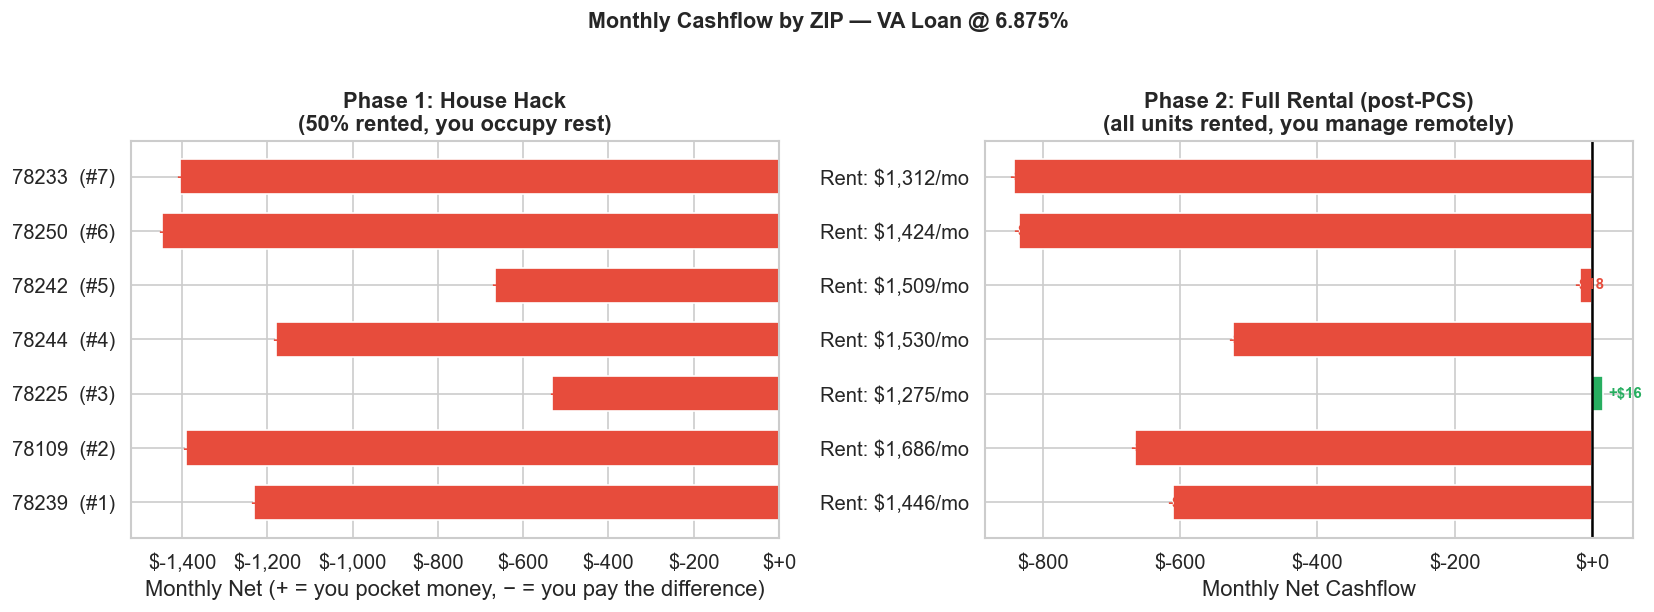

In [4]:
# 3.1 Side-by-side: house hack cost vs full rental cashflow
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(cf) * 0.55)))

zips    = cf['zip']
y_pos   = range(len(cf))

# Phase 1: house hack — your monthly net cost (green = breaking even or better)
ax = axes[0]
hack_vals  = -cf['hack_net_monthly']   # flip sign: positive = money in your pocket
hack_cols  = [POSITIVE_COLOR if v >= 0 else NEGATIVE_COLOR for v in hack_vals]
bars = ax.barh(y_pos, hack_vals, color=hack_cols, edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=1.5)
for bar, val in zip(bars, hack_vals):
    label = f'+${val:,.0f}' if val >= 0 else f'-${abs(val):,.0f}'
    x_off = 8 if val >= 0 else -8
    ha    = 'left' if val >= 0 else 'right'
    ax.text(val + x_off, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9, fontweight='bold',
            color=POSITIVE_COLOR if val >= 0 else NEGATIVE_COLOR)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r['zip']}  (#{r['rank']:.0f})" for _, r in cf.iterrows()])
ax.set_xlabel('Monthly Net (+ = you pocket money, − = you pay the difference)')
ax.set_title(f'Phase 1: House Hack\n({HACK_RENT_FRACTION:.0%} rented, you occupy rest)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))

# Phase 2: full rental
ax2 = axes[1]
full_vals = cf['full_net']
full_cols = [POSITIVE_COLOR if v >= 0 else NEGATIVE_COLOR for v in full_vals]
bars2 = ax2.barh(y_pos, full_vals, color=full_cols, edgecolor='white', height=0.65)
ax2.axvline(0, color='black', linewidth=1.5)
for bar, val in zip(bars2, full_vals):
    label = f'+${val:,.0f}' if val >= 0 else f'-${abs(val):,.0f}'
    x_off = 8 if val >= 0 else -8
    ha    = 'left' if val >= 0 else 'right'
    ax2.text(val + x_off, bar.get_y() + bar.get_height()/2,
             label, va='center', fontsize=9, fontweight='bold',
             color=POSITIVE_COLOR if val >= 0 else NEGATIVE_COLOR)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([f"Rent: ${r['monthly_rent']:,.0f}/mo" for _, r in cf.iterrows()])
ax2.set_xlabel('Monthly Net Cashflow')
ax2.set_title('Phase 2: Full Rental (post-PCS)\n(all units rented, you manage remotely)', fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))

plt.suptitle(f'Monthly Cashflow by ZIP — {LOAN_TYPE} Loan @ {INTEREST_RATE:.3%}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

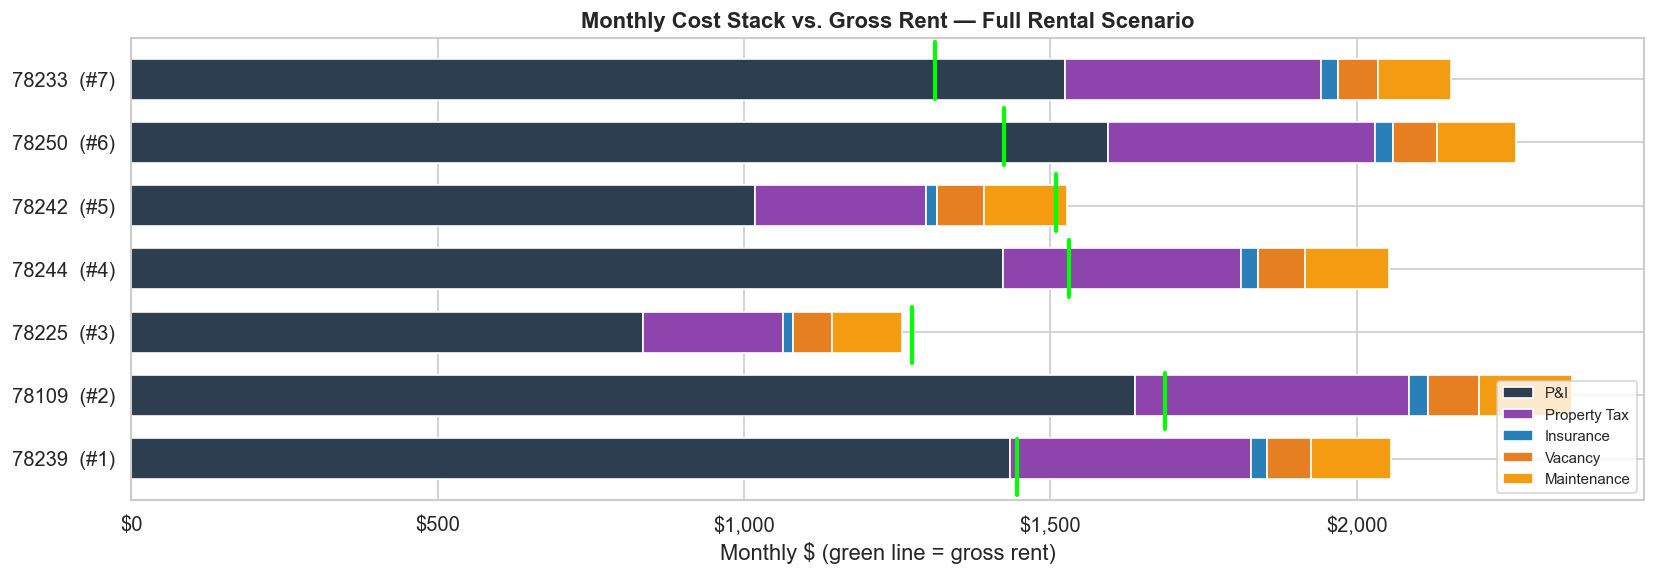


Largest cost component per ZIP:
  78239: P&I = $1,435/mo (70% of total cost)
  78109: P&I = $1,638/mo (70% of total cost)
  78225: P&I = $836/mo (66% of total cost)
  78244: P&I = $1,423/mo (69% of total cost)
  78242: P&I = $1,018/mo (67% of total cost)
  78250: P&I = $1,594/mo (71% of total cost)
  78233: P&I = $1,525/mo (71% of total cost)


In [5]:
# 3.2 Detailed monthly cost stack per ZIP — where does the money go?
fig, ax = plt.subplots(figsize=(14, max(5, len(cf) * 0.65)))

cost_components = {
    'P&I':         cf['monthly_pi'],
    'Property Tax':cf['monthly_tax'],
    'Insurance':   cf['monthly_ins'],
    'HOA':         cf['monthly_hoa'],
    'PMI':         cf['monthly_pmi'],
    'Vacancy':     cf['full_gross'] * VACANCY_RATE,
    'Maintenance': cf['full_gross'] * MAINTENANCE_PCT,
    'Management':  cf['full_gross'] * MGMT_FEE_PCT,
}

colors = ['#2c3e50','#8e44ad','#2980b9','#16a085','#c0392b','#e67e22','#f39c12','#95a5a6']
y_pos  = range(len(cf))
left   = np.zeros(len(cf))

for (label, vals), color in zip(cost_components.items(), colors):
    if vals.sum() == 0:
        continue
    ax.barh(y_pos, vals, left=left, label=label, color=color, edgecolor='white', height=0.65)
    left = left + vals.values

# Overlay gross rent as a marker
for i, (_, row) in enumerate(cf.iterrows()):
    ax.axvline(row['full_gross'], ymin=(i / len(cf)) + 0.01,
               ymax=((i + 1) / len(cf)) - 0.01,
               color='lime', linewidth=2.5, zorder=5)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r['zip']}  (#{r['rank']:.0f})" for _, r in cf.iterrows()])
ax.set_xlabel('Monthly $ (green line = gross rent)')
ax.set_title('Monthly Cost Stack vs. Gross Rent — Full Rental Scenario', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print("\nLargest cost component per ZIP:")
for _, row in cf.iterrows():
    pi_share = row['monthly_pi'] / (row['monthly_piti'] + row['full_gross'] * (VACANCY_RATE + MAINTENANCE_PCT + MGMT_FEE_PCT))
    print(f"  {row['zip']}: P&I = ${row['monthly_pi']:,.0f}/mo ({pi_share:.0%} of total cost)")

**What to look for:** The green line is gross rent. Any ZIP where the stacked cost bar extends past the green line is cash-flow negative as a full rental. Look specifically at how large the P&I bar is relative to everything else — for most ZIPs, your mortgage payment is 55–65% of total cost, which means rate changes hurt disproportionately.

---
## 4. Full Comparison Table

Every number in one place. This is the decision table.

In [6]:
# 4.1 Summary table — all ZIPs, all key metrics
display_cols = {
    'zip':                'ZIP',
    'rank':               'Rank',
    'price':              'Price',
    'monthly_rent':       'Rent/mo',
    'gross_yield':        'Yield',
    'down_payment':       'Down',
    'monthly_piti':       'PITI/mo',
    'hack_rental_income': 'Hack Income',
    'hack_net_monthly':   'Hack Net Cost',
    'full_net':           'Full Rental Net',
    'net_sale_proceed':   '3yr Sale Net',
    'total_3yr_return':   '3yr Total Return',
    'crime_per_1k':       'Crime/1k',
    'commute_minutes':    'Commute',
}

table = cf[list(display_cols.keys())].copy()
table.columns = list(display_cols.values())

def fmt_dollar(v):
    if pd.isna(v): return 'N/A'
    return f'+${v:,.0f}' if v >= 0 else f'-${abs(v):,.0f}'

table['Price']            = table['Price'].map('${:,.0f}'.format)
table['Rent/mo']          = table['Rent/mo'].map('${:,.0f}'.format)
table['Yield']            = table['Yield'].map('{:.1%}'.format)
table['Down']             = table['Down'].map('${:,.0f}'.format)
table['PITI/mo']          = table['PITI/mo'].map('${:,.0f}'.format)
table['Hack Income']      = table['Hack Income'].map('${:,.0f}'.format)
table['Hack Net Cost']    = table['Hack Net Cost'].map(fmt_dollar)
table['Full Rental Net']  = table['Full Rental Net'].map(fmt_dollar)
table['3yr Sale Net']     = table['3yr Sale Net'].map(fmt_dollar)
table['3yr Total Return'] = table['3yr Total Return'].map(fmt_dollar)
table['Crime/1k']         = table['Crime/1k'].map('{:.1f}'.format)
table['Commute']          = table['Commute'].map('{:.0f} min'.format)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 20)
print(table.to_string(index=False))

print(f"\n{'='*60}")
print(f"Hack Net Cost: negative = you're paid to live there")
print(f"Full Rental Net: negative = property costs more than it earns post-PCS")
print(f"3yr Total Return: cumulative hack cashflow + net sale proceeds (${0:.0%} appreciation assumed)")

  ZIP  Rank    Price Rent/mo Yield Down PITI/mo Hack Income Hack Net Cost Full Rental Net 3yr Sale Net 3yr Total Return Crime/1k Commute
78239     1 $213,816  $1,446  8.1%   $0  $1,854        $723       +$1,232           -$610     -$10,113         -$54,460     51.7  15 min
78109     2 $244,063  $1,686  8.3%   $0  $2,116        $843       +$1,391           -$666     -$11,543         -$61,606     42.9  22 min
78225     3 $124,593  $1,275 12.3%   $0  $1,080        $638         +$532            +$16      -$5,893         -$25,039    355.3  16 min
78244     4 $212,064  $1,530  8.7%   $0  $1,838        $765       +$1,180           -$523     -$10,030         -$52,528    114.9  14 min
78242     5 $151,763  $1,509 11.9%   $0  $1,316        $755         +$667            -$18      -$7,178         -$31,178    345.1  29 min
78250     6 $237,592  $1,424  7.2%   $0  $2,060        $712       +$1,447           -$835     -$11,237         -$63,334    166.6  33 min
78233     7 $227,198  $1,312  6.9%   $0  

---
## 5. Sensitivity Analysis

The rate is the number you can't control. The rent is the number you can estimate wrong. These two charts show how sensitive your decision is to each.

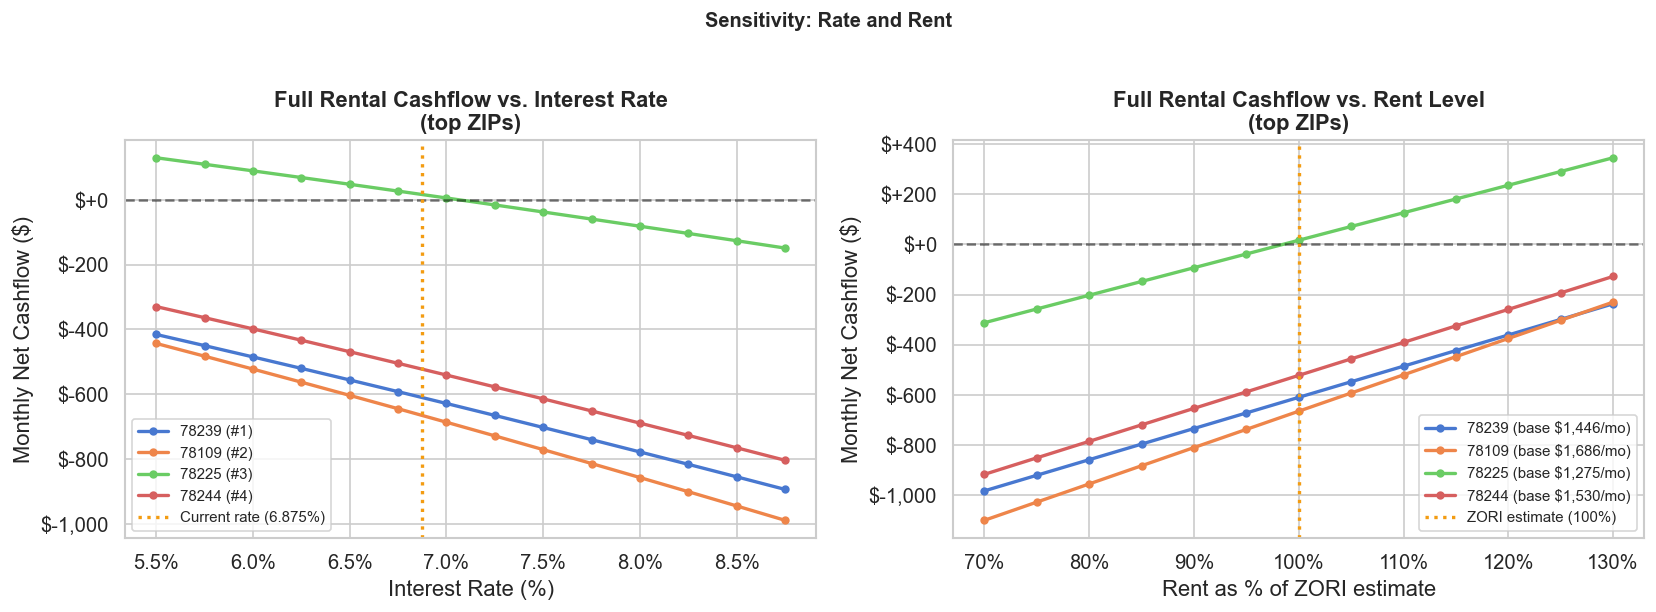

Break-even rent (full rental, current rate):
  78239: need $2,155/mo  (+49.1% vs ZORI $1,446)
  78109: need $2,460/mo  (+45.9% vs ZORI $1,686)
  78225: need $1,256/mo  (-1.5% vs ZORI $1,275)
  78244: need $2,138/mo  (+39.7% vs ZORI $1,530)


In [7]:
# 5.1 Interest rate sensitivity — full rental cashflow
rates      = np.arange(0.055, 0.090, 0.0025)
top_zips   = cf.head(min(4, len(cf)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for _, zip_row in top_zips.iterrows():
    net_by_rate = []
    for rate in rates:
        p = PARAMS.copy()
        p['rate'] = rate
        result = full_cashflow(
            scored[scored['zip'] == zip_row['zip']].iloc[0], p
        )
        net_by_rate.append(result['full_net'])
    ax.plot(rates * 100, net_by_rate, linewidth=2,
            label=f"{zip_row['zip']} (#{zip_row['rank']:.0f})", marker='o', markersize=4)

ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
ax.axvline(INTEREST_RATE * 100, color=WARN_COLOR, linewidth=2, linestyle=':',
           label=f'Current rate ({INTEREST_RATE:.3%})')
ax.set_xlabel('Interest Rate (%)')
ax.set_ylabel('Monthly Net Cashflow ($)')
ax.set_title('Full Rental Cashflow vs. Interest Rate\n(top ZIPs)', fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# 5.2 Rent sensitivity — what rent do you need to break even?
ax2 = axes[1]
rent_multipliers = np.arange(0.70, 1.31, 0.05)

for _, zip_row in top_zips.iterrows():
    base_rent = scored[scored['zip'] == zip_row['zip']]['median_rent'].values[0]
    net_by_rent = []
    for mult in rent_multipliers:
        # Temporarily override rent
        row_copy = scored[scored['zip'] == zip_row['zip']].iloc[0].copy()
        row_copy['median_rent'] = base_rent * mult
        result = full_cashflow(row_copy, PARAMS)
        net_by_rent.append(result['full_net'])
    ax2.plot(rent_multipliers * 100, net_by_rent, linewidth=2,
             label=f"{zip_row['zip']} (base ${base_rent:,.0f}/mo)", marker='o', markersize=4)

ax2.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
ax2.axvline(100, color=WARN_COLOR, linewidth=2, linestyle=':',
            label='ZORI estimate (100%)')
ax2.set_xlabel('Rent as % of ZORI estimate')
ax2.set_ylabel('Monthly Net Cashflow ($)')
ax2.set_title('Full Rental Cashflow vs. Rent Level\n(top ZIPs)', fontweight='bold')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.suptitle('Sensitivity: Rate and Rent', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Break-even rents
print("Break-even rent (full rental, current rate):")
for _, zip_row in top_zips.iterrows():
    row = scored[scored['zip'] == zip_row['zip']].iloc[0]
    # Binary search for break-even rent
    lo, hi = row['median_rent'] * 0.5, row['median_rent'] * 2.0
    for _ in range(40):
        mid = (lo + hi) / 2
        r   = row.copy(); r['median_rent'] = mid
        if full_cashflow(r, PARAMS)['full_net'] >= 0:
            hi = mid
        else:
            lo = mid
    pct_above = (hi / row['median_rent'] - 1) * 100
    print(f"  {zip_row['zip']}: need ${hi:,.0f}/mo  "
          f"({pct_above:+.1f}% vs ZORI ${row['median_rent']:,.0f})")

**What to look for:** The break-even rent table is the most actionable output in this section. If break-even is 5–10% above ZORI, it's achievable — ZORI is a smoothed index and individual listings can easily be 10% above median. If break-even is 20%+ above ZORI, the property needs market rents significantly above the ZIP average to work — that requires specific property type (duplex vs SFH rooms) and condition to justify.

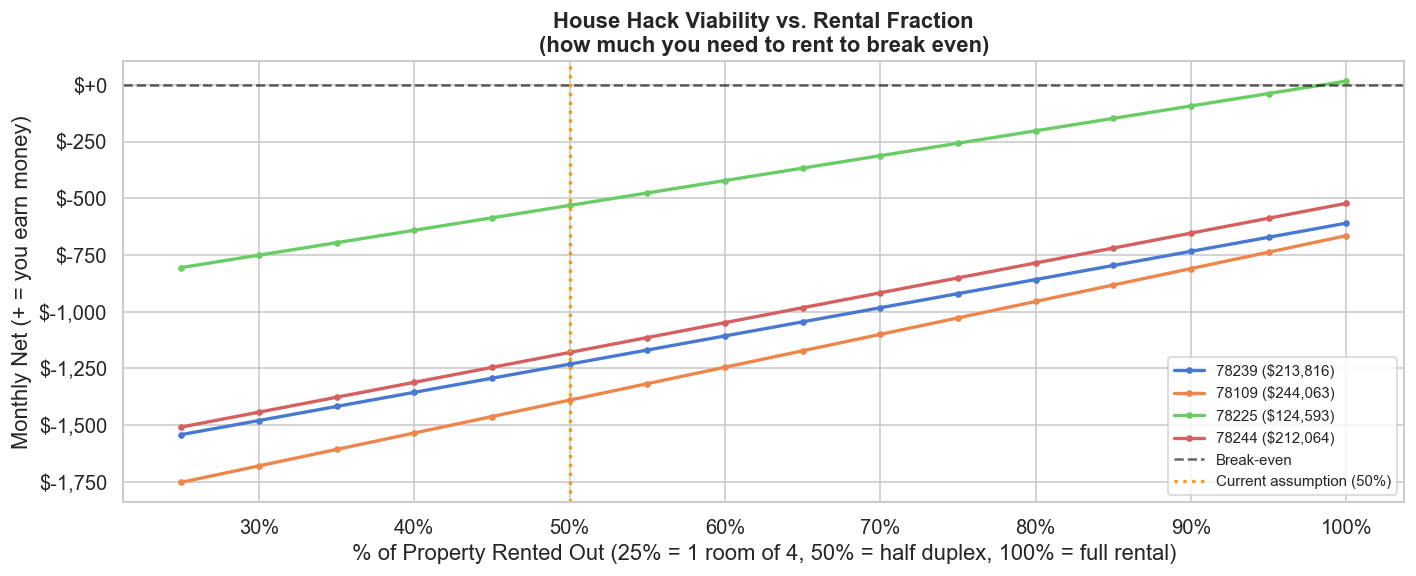

Minimum rental fraction to break even (monthly):
  78239: need to rent 100% of property  (more than half — SFH tough)
  78109: need to rent 100% of property  (more than half — SFH tough)
  78225: need to rent 99% of property  (more than half — SFH tough)
  78244: need to rent 100% of property  (more than half — SFH tough)


In [8]:
# 5.3 Hack fraction sensitivity — how much do you need to rent out?
# Key question: does renting 1 room vs 2 rooms vs a full unit change viability?
fig, ax = plt.subplots(figsize=(12, 5))

hack_fracs = np.arange(0.25, 1.01, 0.05)
for _, zip_row in top_zips.iterrows():
    row      = scored[scored['zip'] == zip_row['zip']].iloc[0]
    costs_by_frac = []
    for frac in hack_fracs:
        p = PARAMS.copy(); p['hack_frac'] = frac
        result = full_cashflow(row, p)
        costs_by_frac.append(-result['hack_net_monthly'])  # positive = money in pocket
    ax.plot(hack_fracs * 100, costs_by_frac, linewidth=2,
            label=f"{zip_row['zip']} (${zip_row['price']:,.0f})", marker='o', markersize=3)

ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.6, label='Break-even')
ax.axvline(HACK_RENT_FRACTION * 100, color=WARN_COLOR, linewidth=2,
           linestyle=':', label=f'Current assumption ({HACK_RENT_FRACTION:.0%})')
ax.set_xlabel('% of Property Rented Out (25% = 1 room of 4, 50% = half duplex, 100% = full rental)')
ax.set_ylabel('Monthly Net (+ = you earn money)')
ax.set_title('House Hack Viability vs. Rental Fraction\n(how much you need to rent to break even)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

# Find minimum fraction needed to break even
print("Minimum rental fraction to break even (monthly):")
for _, zip_row in top_zips.iterrows():
    row = scored[scored['zip'] == zip_row['zip']].iloc[0]
    lo, hi = 0.01, 1.00
    for _ in range(40):
        mid = (lo + hi) / 2
        p   = PARAMS.copy(); p['hack_frac'] = mid
        if full_cashflow(row, p)['hack_net_monthly'] <= 0:
            hi = mid
        else:
            lo = mid
    print(f"  {zip_row['zip']}: need to rent {hi:.0%} of property  "
          f"({'duplex 1 unit' if hi <= 0.52 else 'more than half — SFH tough'})")

---
## 6. 3-Year Hold P&L

The full picture of what happens between purchase and PCS — cumulative cashflow plus what you walk away with at the sale.

**$0 appreciation assumption is intentional.** SA has appreciated strongly but past appreciation is not guaranteed. This forces the investment to stand on cashflow merit alone. If it works at $0 appreciation, any actual appreciation is upside.

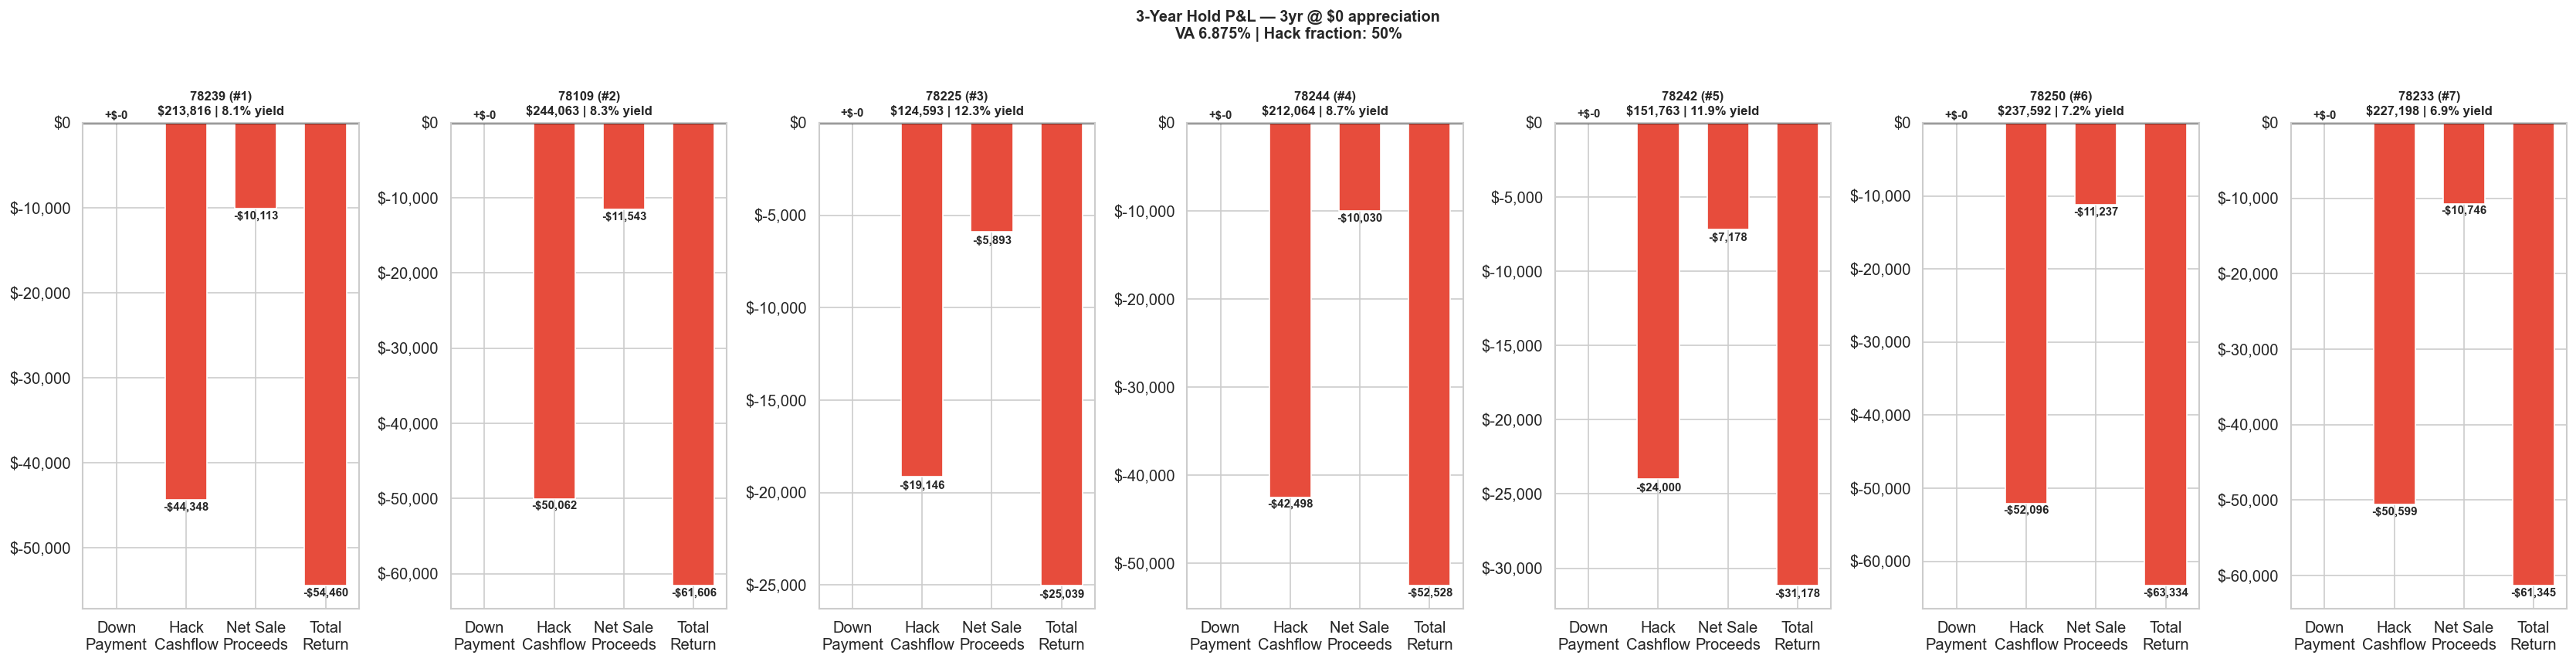

In [9]:
# 6.1 3-year waterfall: where does money flow?
fig, axes = plt.subplots(1, len(cf), figsize=(4 * len(cf), 7), sharey=False)
if len(cf) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, cf.iterrows()):
    components = {
        'Down\nPayment':    -row['down_payment'],
        'Hack\nCashflow':   row['cumulative_hack_cf'],
        'Net Sale\nProceeds': row['net_sale_proceed'],
        'Total\nReturn':    row['total_3yr_return'],
    }

    colors_wf = []
    for k, v in components.items():
        if k == 'Total\nReturn':
            colors_wf.append(POSITIVE_COLOR if v >= 0 else NEGATIVE_COLOR)
        elif k == 'Down\nPayment':
            colors_wf.append('#7f8c8d')
        else:
            colors_wf.append(POSITIVE_COLOR if v >= 0 else NEGATIVE_COLOR)

    bars = ax.bar(list(components.keys()), list(components.values()),
                  color=colors_wf, edgecolor='white', width=0.6)
    ax.axhline(0, color='black', linewidth=1.5)

    for bar, val in zip(bars, components.values()):
        label = f'+${val:,.0f}' if val >= 0 else f'-${abs(val):,.0f}'
        y_pos_label = val + 200 if val >= 0 else val - 200
        va = 'bottom' if val >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width()/2, y_pos_label,
                label, ha='center', va=va, fontsize=9, fontweight='bold')

    ax.set_title(f"{row['zip']} (#{row['rank']:.0f})\n"
                 f"${row['price']:,.0f} | {row['gross_yield']:.1%} yield",
                 fontweight='bold', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_xlabel('')

plt.suptitle(f'3-Year Hold P&L — {HOLD_YEARS}yr @ $0 appreciation\n'
             f'{LOAN_TYPE} {INTEREST_RATE:.3%} | Hack fraction: {HACK_RENT_FRACTION:.0%}',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

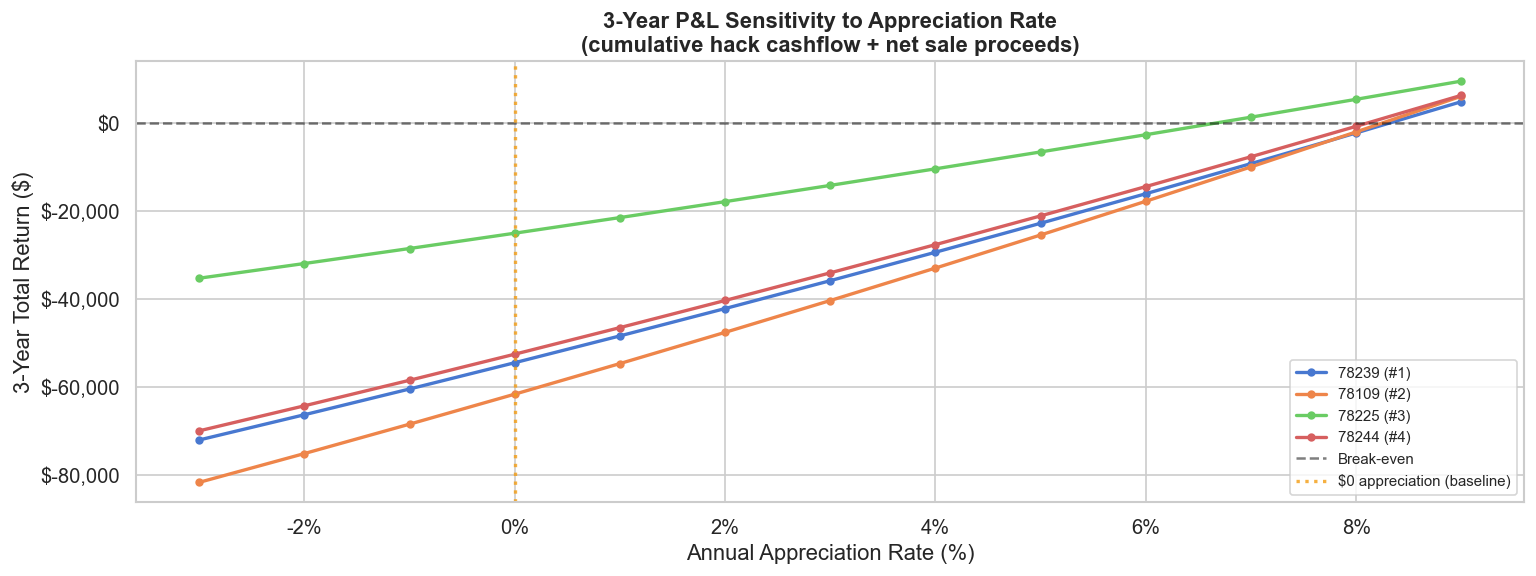

Appreciation rate needed to break even over 3 years:
  78239: need 8.3%/yr appreciation to break even
  78109: need 8.3%/yr appreciation to break even
  78225: need 6.7%/yr appreciation to break even
  78244: need 8.1%/yr appreciation to break even


In [10]:
# 6.2 What does the 3-year P&L look like at different appreciation rates?
# $0 is conservative. SA has averaged ~6%/yr 2019-2024. What does -3% to +8% do?
appreciation_rates = np.arange(-0.03, 0.091, 0.01)

fig, ax = plt.subplots(figsize=(13, 5))
for _, zip_row in top_zips.iterrows():
    row = scored[scored['zip'] == zip_row['zip']].iloc[0]
    returns_by_appr = []
    for appr in appreciation_rates:
        p = PARAMS.copy(); p['appreciation'] = appr
        result = full_cashflow(row, p)
        returns_by_appr.append(result['total_3yr_return'])
    ax.plot(appreciation_rates * 100, returns_by_appr, linewidth=2,
            label=f"{zip_row['zip']} (#{zip_row['rank']:.0f})", marker='o', markersize=4)

ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5, label='Break-even')
ax.axvline(0, color=WARN_COLOR, linewidth=2, linestyle=':', alpha=0.8,
           label='$0 appreciation (baseline)')
ax.set_xlabel('Annual Appreciation Rate (%)')
ax.set_ylabel('3-Year Total Return ($)')
ax.set_title('3-Year P&L Sensitivity to Appreciation Rate\n(cumulative hack cashflow + net sale proceeds)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

# Appreciation rate needed to break even on the whole deal
print("Appreciation rate needed to break even over 3 years:")
for _, zip_row in top_zips.iterrows():
    row = scored[scored['zip'] == zip_row['zip']].iloc[0]
    lo, hi = -0.10, 0.20
    for _ in range(50):
        mid = (lo + hi) / 2
        p = PARAMS.copy(); p['appreciation'] = mid
        if full_cashflow(row, p)['total_3yr_return'] >= 0:
            hi = mid
        else:
            lo = mid
    print(f"  {zip_row['zip']}: need {hi:.1%}/yr appreciation to break even")

---
## 7. Decision Scorecard

One cell to read before making any move on a specific property.

In [11]:
# 7. Final scorecard — traffic-light assessment per ZIP
print(f"{'='*75}")
print(f"{'PROPERTY DECISION SCORECARD':^75}")
print(f"{'VA Loan @ ' + f'{INTEREST_RATE:.3%}' + ' | Bexar Co. 2.2% tax | ' + f'{HACK_RENT_FRACTION:.0%} rented while living':^75}")
print(f"{'='*75}")

for _, row in cf.iterrows():
    hack_ok   = row['hack_net_monthly'] <= 0          # break even or better
    rental_ok = row['full_net'] >= -200               # within $200 of breaking even
    yield_ok  = row['gross_yield'] >= 0.075           # strong yield
    crime_ok  = row.get('crime_per_1k', 999) < 100   # meaningful safety threshold
    return_ok = row['total_3yr_return'] >= -5000      # doesn't destroy value

    def flag(condition, good='✓', bad='✗'):
        return good if condition else bad

    print(f"\n  ZIP {row['zip']}  (Model rank #{row['rank']:.0f})")
    print(f"  {'─'*55}")
    print(f"  {flag(hack_ok)}  House hack monthly: "
          f"{'${:,.0f} in your pocket'.format(-row['hack_net_monthly']) if hack_ok else '${:,.0f} out of pocket'.format(row['hack_net_monthly'])}")
    print(f"  {flag(rental_ok)}  Full rental monthly net: ${row['full_net']:+,.0f}")
    print(f"  {flag(yield_ok)}  Gross yield: {row['gross_yield']:.1%}  "
          f"{'(above 7.5% target)' if yield_ok else '(below 7.5% target)'}")
    print(f"  {flag(crime_ok)}  Crime rate: {row.get('crime_per_1k', 0):.0f}/1k  "
          f"{'(under 100 — acceptable)' if crime_ok else '(over 100 — elevated)'}")
    print(f"  {flag(return_ok)}  3yr total return @ $0 appreciation: ${row['total_3yr_return']:+,.0f}")

    all_pass = hack_ok and rental_ok and return_ok
    print(f"\n  → {'INVESTIGATE SERIOUSLY' if all_pass else 'NEEDS GROUND TRUTH ON: ' + ', '.join(filter(None, ['rent level' if not rental_ok else None, 'yield' if not yield_ok else None, '3yr return' if not return_ok else None]))}")

print(f"\n{'='*75}")
print("Next step: for any ZIP marked INVESTIGATE SERIOUSLY,")
print("pull 5-10 current active listings on Zillow/Realtor and verify rents.")
print(f"{'='*75}")

                        PROPERTY DECISION SCORECARD                        
      VA Loan @ 6.875% | Bexar Co. 2.2% tax | 50% rented while living      

  ZIP 78239  (Model rank #1)
  ───────────────────────────────────────────────────────
  ✗  House hack monthly: $1,232 out of pocket
  ✗  Full rental monthly net: $-610
  ✓  Gross yield: 8.1%  (above 7.5% target)
  ✓  Crime rate: 52/1k  (under 100 — acceptable)
  ✗  3yr total return @ $0 appreciation: $-54,460

  → NEEDS GROUND TRUTH ON: rent level, 3yr return

  ZIP 78109  (Model rank #2)
  ───────────────────────────────────────────────────────
  ✗  House hack monthly: $1,391 out of pocket
  ✗  Full rental monthly net: $-666
  ✓  Gross yield: 8.3%  (above 7.5% target)
  ✓  Crime rate: 43/1k  (under 100 — acceptable)
  ✗  3yr total return @ $0 appreciation: $-61,606

  → NEEDS GROUND TRUTH ON: rent level, 3yr return

  ZIP 78225  (Model rank #3)
  ───────────────────────────────────────────────────────
  ✗  House hack monthly: $532 ou

---
## 8. What This Model Cannot Tell You

The scorecard is a filter, not a verdict. Before acting on any result:

**Verify rent with actual listings.** ZORI is a smoothed ZIP-level index. The specific property type (duplex vs SFH with rooms vs ADU) dramatically changes achievable rent. Pull 5–10 active listings in the ZIP that match your target property type.

**Get a real insurance quote.** The $1.50/1k estimate can swing ±40% based on age, construction type, claims history, and flood zone. SA has no shortage of flood-adjacent properties.

**Confirm property tax with Bexar CAD.** The 2.2% effective rate is a county average. Individual parcels vary. Also: Texas homestead exemption reduces your taxable value by $100k (2023 law) — if you qualify and apply, your actual tax bill is lower than this model shows.

**Model assumes you self-manage.** The `MGMT_FEE_PCT = 0.00` assumption disappears the moment you PCS. Set it to `0.08` and re-run to see what professional management does to your full-rental cashflow — that's the number you'll actually live with post-PCS.

**Duplex vs SFH rooms vs ADU are different businesses.** This model uses `HACK_RENT_FRACTION` as a blunt lever. A duplex at 50% is cleaner, more defensible legally, and easier to manage than renting rooms in an SFH. Run the scorecard separately for each property type you're considering.